---
title: "Lecture 3: Discrete Random Variables, Expectation"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture3_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
        html-math-method: katex
    html: 
        code-fold: true
        embed-resources: true
        output-file: Lecture3
        code-links:
          - text: "Open in Colab"
            href: "https://colab.research.google.com/github/jamiehadd/Math-151-Probability/blob/main/03_discrete-random-variables-expectation.ipynb"
            icon: "laptop"
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        output-file: Lecture3
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: python3
colab:
  gh-user: "jamiehadd"
  gh-repo: "Math-151-Probability"
filters: 
  - input/remove-pause.lua
  - colab
execute:
  echo: true
  eval: true
---

## Why counting?

Many of the probability laws we'll compute with live on **finite** sample spaces where
every outcome is equally likely (the *discrete uniform* law):
$$
P(A) = \frac{|A|}{|\Omega|}.
$$

. . .

So computing probabilities often reduces to **counting** outcomes carefully. We'll build
four counting tools today: the counting principle, $k$-permutations, combinations, and
partitions.

## The counting principle

::: {.callout-note}
## Definition: Counting principle
Suppose a task consists of $r$ stages performed in sequence. If stage 1 has $n_1$ possible
outcomes, and for every outcome of stage 1 there are $n_2$ possible outcomes of stage 2,
and so on, then the total number of possible outcomes of the $r$-stage task is
$$
n_1 \cdot n_2 \cdots n_r.
$$
:::

**Example: how many subsets does an $n$-element set have?**

Think of building a subset $S \subseteq \{1,\dots,n\}$ as an $n$-stage task: for each
element, decide "in $S$" or "not in $S$" — 2 choices, made $n$ times in a row.

. . .

By the counting principle, the number of subsets of an $n$-element set is $2^n$.

## $k$-permutations, combinations, partitions

Five students in our probability reading group: **Alice, Bob, Carol, Dave, Eve**.

**$k$-permutations.** In how many ways can we choose an *ordered* 1st/2nd/3rd place
finish among the 5, in a problem-solving contest?
$$
5 \cdot 4 \cdot 3 = \frac{5!}{(5-3)!} = 60.
$$
In general, the number of $k$-permutations of an $n$-element set is $\dfrac{n!}{(n-k)!}$.

---

**Combinations.** In how many ways can we choose an *unordered* team of 3 to present at a
conference? Each unordered team of 3 corresponds to $3! = 6$ orders in the $5!$ permutations, so
$$
\binom{5}{3} = \frac{60}{3!} = 10, \qquad \text{in general } \binom{n}{k} = \frac{n!}{k!(n-k)!}.
$$

. . .

**Partitions.** In how many ways can we split the five students and professor (six people in total) into one two-person team to go to conference session A, one two-person team to go to conference session B, and one two person-team to go to conference session C? Choose an ordering of the six people and divide the group into three groups of two, then account for each groups' $2!$ overcounting, so
$$
\frac{6!}{2!\, 2!\, 2!} = 90, \qquad \text{in general (into groups of sizes $n_1,\dots,n_r$): } \frac{n!}{n_1!\, n_2! \cdots n_r!}.
$$

## Counting summary

::: {.callout-tip}
## Four counting formulas
| Quantity | Formula |
|---|---|
| # subsets of an $n$-element set | $2^n$ |
| # $k$-permutations of $n$ elements | $\dfrac{n!}{(n-k)!}$ |
| # $k$-combinations of $n$ elements | $\dbinom{n}{k} = \dfrac{n!}{k!(n-k)!}$ |
| # partitions into groups of sizes $n_1,\dots,n_r$ | $\dfrac{n!}{n_1!\,n_2!\cdots n_r!}$ |
:::

## Random variables

::: {.callout-note}
## Definition: Random variable
Given a probability space $(\Omega, P)$, a **random variable (RV)** is a function
$$
X : \Omega \to \mathbb{R}
$$
that assigns a real number $X(\omega)$ to every outcome $\omega \in \Omega$.
:::

. . .

::: {.callout-warning}
## Notation
A random variable is a *deterministic function* — the randomness comes entirely from
which $\omega$ occurs, not from $X$ itself. We use **capital $X$** for the random
variable (the function), and **lowercase $x$** for a specific numerical value $X$ might
take.
:::

## Functions of random variables

If $X$ is a random variable and $g : \mathbb{R} \to \mathbb{R}$ is any function, then
$Y = g(X)$ is also a random variable, defined by $Y(\omega) = g(X(\omega))$.

**Example:** Roll a fair die, $\Omega = \{1,\dots,6\}$, and let
$X(\omega) = \omega$ be the face shown. Suppose the payout rule is: win \$2 if the roll
is even, lose \$1 if the roll is odd. Then $Y = g(X)$ where
$$
g(x) = \begin{cases} 2 & x \text{ even} \\ -1 & x \text{ odd} \end{cases}
$$
is itself a random variable on the same sample space.

## Discrete random variables

::: {.callout-note}
## Definition: Discrete random variable
A random variable $X$ is **discrete** if its range — the set of values it can take — is
finite or countably infinite.
:::

**Examples:** a die roll; the payout $Y$ above; the number of heads in $n$ coin flips;
the number of flips until the first head (range $\{1,2,3,\dots\}$ — infinite, but still
*countable*, hence discrete).

. . .

A **continuous** random variable, by contrast, takes values in an uncountable range (an
interval of $\mathbb{R}$) — we'll get there in a few lectures.

## Is the randomized Kaczmarz error discrete?

Recall randomized Kaczmarz (RK), solving $Ax = b$: at each step we sample a row index
$I \in \{1,\dots,m\}$ at random and update
$$
x_{k+1} = x_k + \frac{b_I - a_I^\top x_k}{\lVert a_I \rVert^2}\, a_I .
$$

$I$ is clearly a **discrete** RV — only $m$ possible values.

. . .

But consider $E = \lVert x_{k+1} - x^\star \rVert$, the error *after* this step. For fixed
$x_k$, $E$ looks continuous: it's a norm of a real vector, and could in principle be any
real number.

. . .

::: {.callout-tip}
## Functions of discrete RVs are discrete!
$E$ is a **function of the discrete RV $I$**: $E = h(I)$ for some function $h$. Since $I$
takes only $m$ values, $E$ *also* has a range of at most $m$ values — even though each of
those $m$ values is an arbitrary real number, not an integer. **Discreteness is
about the size of the range, not about the values themselves.**
:::

## The probability mass function (PMF)

::: {.callout-note}
## Definition: PMF
For a discrete random variable $X$, the **probability mass function** is
$$
p_X(x) = P(X = x) = P(\{\omega \in \Omega : X(\omega) = x\}), \qquad \text{for each possible value } x.
$$
:::

Notice the notation: $p_X$ is indexed by the *random variable* $X$, and evaluated at
a *candidate value* $x$.

. . .

**Properties:** $p_X(x) \ge 0$ for all $x$, and $\displaystyle\sum_x p_X(x) = 1$, where the
sum is over the range of $X$.

**To calculate $p_X(x)$:** collect every outcome $\omega$ with $X(\omega) = x$, and sum
their probabilities under $P$.

## Example: the PMF of $Y$ (the dice-game payout)

Recall $X$ is the die roll (uniform on $\{1,\dots,6\}$) and $Y = g(X)$ pays \$2 on even,
$-\$1$ on odd. Grouping outcomes by their value of $Y$:
$$
p_Y(2) = P(X \in \{2,4,6\}) = \tfrac{3}{6} = \tfrac12, \qquad
p_Y(-1) = P(X \in \{1,3,5\}) = \tfrac{3}{6} = \tfrac12.
$$

## Five named discrete distributions

::: {.callout-note}
## Bernoulli($p$)
$X \in \{0,1\}$, $p_X(1) = p$, $p_X(0) = 1-p$, for
$p \in [0,1]$.
:::

Examples: coin tossing, rain/no rain

. . .

::: {.callout-note}
## Rademacher
$X \in \{-1,+1\}$, $p_X(-1) = p_X(1) = \tfrac12$. 
:::

Examples: coin tossing, rain/no rain, these appear a lot in randomized algorithms (when we often want a binary r.v. which is centered on 0)

## Five named discrete distributions, continued

::: {.callout-note}
## Binomial($n,p$)
$X$ is the number of successes in $n$ independent Bernoulli($p$) trials. Range $\{0,1,\dots,n\}$.
Choosing *which* $k$ of the $n$ trials succeed is a combinations count from Part 1:
$$
p_X(k) = \binom{n}{k} p^k (1-p)^{n-k}.
$$
:::

Examples: number of defective products out of $n$ total, number of patients experiencing side effect out of $n$ total

. . .

::: {.callout-note}
## Geometric($p$)
$X$ is the number of independent Bernoulli($p$) trials up to *and including* the first success.
Range $\{1,2,3,\dots\}$:
$$
p_X(k) = (1-p)^{k-1} p.
$$
:::

Examples: number of cold calls until first sale, number of free throws until first made

## Five named discrete distributions, continued

::: {.callout-note}
## Poisson($\lambda$)
$X$ counts the number of (rare) events occuring in a fixed interval of time if they occur with mean rate $\lambda$ and independently of the last time they occured.  Range $\{0, 1, 2, \dots\}:$
$$
p_X(k) = e^{-\lambda} \frac{\lambda^k}{k!}.
$$
:::

Examples: number of major earthquakes in a region over the past century, number of emails received over an hour

. . .

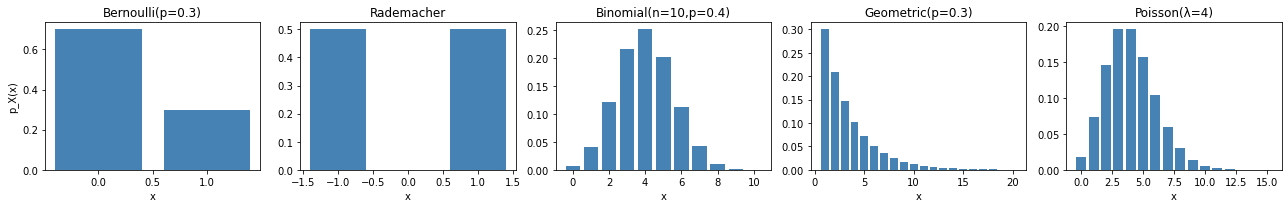

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb, exp, factorial

fig, axes = plt.subplots(1, 5, figsize=(18, 3))

# Bernoulli(p)
p = 0.3
axes[0].bar([0, 1], [1 - p, p], color="steelblue")
axes[0].set_title(f"Bernoulli(p={p})")

# Rademacher
axes[1].bar([-1, 1], [0.5, 0.5], color="steelblue")
axes[1].set_title("Rademacher")

# Binomial(n,p)
n_b, p_b = 10, 0.4
ks_b = np.arange(0, n_b + 1)
pmf_b = [comb(n_b, k) * p_b**k * (1 - p_b) ** (n_b - k) for k in ks_b]
axes[2].bar(ks_b, pmf_b, color="steelblue")
axes[2].set_title(f"Binomial(n={n_b},p={p_b})")

# Geometric(p)
p_g = 0.3
ks_g = np.arange(1, 21)
pmf_g = [(1 - p_g) ** (k - 1) * p_g for k in ks_g]
axes[3].bar(ks_g, pmf_g, color="steelblue")
axes[3].set_title(f"Geometric(p={p_g})")

# Poisson(lambda)
lam = 4
ks_p = np.arange(0, 16)
pmf_p = [exp(-lam) * lam**k / factorial(k) for k in ks_p]
axes[4].bar(ks_p, pmf_p, color="steelblue")
axes[4].set_title(f"Poisson(λ={lam})")

for ax in axes:
    ax.set_xlabel("x")
axes[0].set_ylabel("p_X(x)")

plt.tight_layout()
plt.show()

## Aside: Poisson as a limit of Binomial

::: {.callout-tip}
## Fact
If $n \to \infty$ and $p \to 0$ with $np = \lambda$ held fixed, Binomial($n,p$) PMF
converges pointwise to Poisson($\lambda$) PMF.
:::

This is why Poisson is the right model for counts of rare events out of *many*
opportunities for them to occur (e.g., typos on a page, radioactive decays per second).

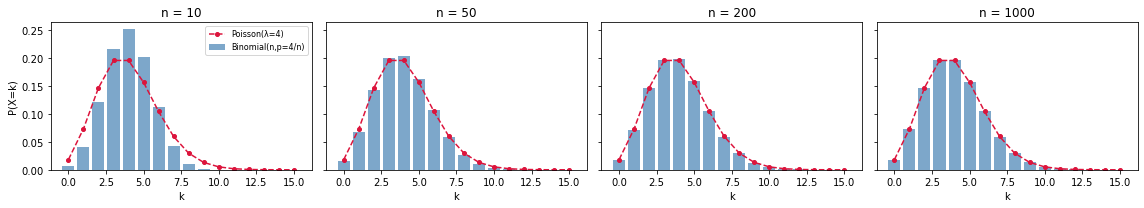

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb, exp, factorial

lam = 4
ks = np.arange(0, 16)
poisson_pmf = np.array([exp(-lam) * lam**k / factorial(k) for k in ks])

ns = [10, 50, 200, 1000]
fig, axes = plt.subplots(1, len(ns), figsize=(16, 3), sharey=True)

for ax, n_ in zip(axes, ns):
    p_ = lam / n_
    binom_pmf = np.array([comb(n_, k) * p_**k * (1 - p_) ** (n_ - k) for k in ks])
    ax.bar(ks, binom_pmf, color="steelblue", alpha=0.7, label=f"Binomial(n,p={lam}/n)")
    ax.plot(ks, poisson_pmf, "o--", color="crimson", markersize=4, label=f"Poisson(λ={lam})")
    ax.set_title(f"n = {n_}")
    ax.set_xlabel("k")

axes[0].set_ylabel("P(X=k)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Expectation

Back to the dice game: win \$2 on even, lose \$1 on odd. If we played this an enormous
number of times, what's the average payout per play?

. . .

Intuitively: a fraction $p_Y(2) = \tfrac12$ of plays pay \$2, and a fraction
$p_Y(-1)=\tfrac12$ pay $-\$1$, so the long-run average per play should be
$$
2 \cdot \tfrac12 + (-1)\cdot\tfrac12 = 0.5.
$$

. . .

::: {.callout-note}
## Definition: Expectation
The **expected value** (or **mean**) of a discrete RV $X$ with PMF $p_X$ is
$$
E[X] = \sum_x x\, p_X(x),
$$
summed over the range of $X$ (assuming the sum is well defined when the range is infinite).
:::

. . .

$E[X]$ is a single number summarizing the "center" of $X$'s distribution — not necessarily
a value $X$ can even take (e.g. our dice game has $E[Y]=0.5$, but $Y$ only ever takes the
values $2$ or $-1$!).

## Compute $E[X]$ for each named distribution

**Bernoulli($p$):** $\ E[X] = 0\cdot(1-p) + 1\cdot p = p$

. . .

**Rademacher:** $\ E[X] = (-1)\cdot\tfrac12 + 1\cdot\tfrac12 = 0$

. . .

::: {.callout-caution}
## In-class activity
Work with your neighbors to compute $E[X]$ for each of Binomial,
Geometric, and Poisson. 
:::

---

**Binomial($n,p$):** 
$$
\begin{aligned}
E[X] &= \sum_{k=0}^n k\binom{n}{k}p^k(1-p)^{n-k} = \sum_{k=1}^{n} k \frac{n!}{(n-k)!\, k!} p^k(1-p)^{n-k} \\&= \sum_{k=1}^{n} np \frac{(n-1)!}{((n-1) - (k-1))!\, (k-1)!} p^{k-1}(1-p)^{(n-1) - (k-1)} \\&= np \sum_{k=0}^{n-1} \frac{(n-1)!}{((n-1) - k)!\, k!} p^{k}(1-p)^{(n-1) - k} \\&= np
\end{aligned}
$$

---

**Geometric($p$):** 
$$
\begin{aligned}
E[X] &= \sum_{k=1}^\infty k(1-p)^{k-1}p = p \sum_{k=1}^\infty \frac{d}{dy} y^k = p \frac{d}{dy} \sum_{k=1}^\infty y^k = p \frac{d}{dy} \frac{y}{1-y} = p \frac{1}{(1-y)^2} = \frac1p
\end{aligned}
$$ where $y = 1-p$

---

**Poisson($\lambda$):** 
$$
\begin{aligned}
E[X] &= \sum_{k=0}^\infty k\, e^{-\lambda}\frac{\lambda^k}{k!} =  \lambda \sum_{k=1}^\infty e^{-\lambda}\frac{\lambda^{k-1}}{(k-1)!} = \lambda \sum_{k=0}^\infty e^{-\lambda}\frac{\lambda^{k}}{k!} = \lambda
\end{aligned}
$$

. . .

In [24]:
import numpy as np

rng = np.random.default_rng(151)
N = 500_000

p = 0.3
bernoulli = (rng.random(N) < p).astype(float)

rademacher = rng.choice([-1.0, 1.0], size=N)

n_b, p_b = 10, 0.4
binomial = rng.binomial(n_b, p_b, size=N).astype(float)

p_g = 0.3
geometric = rng.geometric(p_g, size=N).astype(float)

lam = 4
poisson = rng.poisson(lam, size=N).astype(float)

rows = [
    ("Bernoulli(p=0.3)",        bernoulli.mean(), p),
    ("Rademacher",              rademacher.mean(), 0.0),
    ("Binomial(n=10,p=0.4)",    binomial.mean(),  n_b * p_b),
    ("Geometric(p=0.3)",        geometric.mean(), 1 / p_g),
    ("Poisson(λ=4)",            poisson.mean(),   float(lam)),
]

print(f"{'distribution':<22}{'simulated E[X]':>16}{'theory':>12}")
for name, sim, theory in rows:
    print(f"{name:<22}{sim:>16.4f}{theory:>12.4f}")

distribution            simulated E[X]      theory
Bernoulli(p=0.3)                0.3003      0.3000
Rademacher                      0.0001      0.0000
Binomial(n=10,p=0.4)            3.9963      4.0000
Geometric(p=0.3)                3.3348      3.3333
Poisson(λ=4)                    3.9935      4.0000


## Example: the Quiz Problem

A contestant is asked two questions, in an order of *their own* choosing. Get a question
right and you win its prize; get it wrong and the quiz ends immediately — you forfeit
everything still to come.

Say Question 1 is answered correctly with probability $p_1=0.8$, worth $v_1=\$100$; Question 2 is
answered correctly with probability $p_2=0.5$, worth $v_2=\$200$.
**Which should you answer first?**

. . .

The answer is not obvious because there is a tradeoff.  You certainly want the chance to answer the more valuable Question 2, but if you attempt it first, you may never get a chance to attempt the easier Question 1.  Let's look at expected winnings under the two orderings!

## Working it out directly

**Ask Question 1 first.** You win \$100 if you get it right (probability $0.8$), and *on
top of that* you win \$200 if you also get Question 2 right (probability $0.8\times 0.5$):
$$
E[X] = p_1v_1 + p_1p_2v_2 = (0.8)(100) + (0.8)(0.5)(200) = 80+80 = 160.
$$

. . .

**Ask Question 2 first instead:**
$$
E[X] = p_2v_2 + p_2p_1v_1 = (0.5)(200) + (0.5)(0.8)(100) = 100+40 = 140.
$$


## The general case

Now the same question in general: Question $i$ is answered correctly with probability
$p_i$ and is worth $v_i$ if correct; an incorrect answer ends the quiz. **In general, which
order maximizes expected total winnings?**

. . .

Exactly the same reasoning as above: if question $i$ is asked first and $j$ second,
$$
E[X] = p_i v_i + p_i p_j v_j.
$$

. . .

Asking $1$ first beats asking $2$ first exactly when
$$
p_1 v_1 + p_1 p_2 v_2 > p_2 v_2 + p_1 p_2 v_1
\iff
\frac{p_1 v_1}{1-p_1} > \frac{p_2 v_2}{1-p_2}.
$$

---

::: {.callout-tip}
## Rule
Ask questions in **decreasing order of** $\dfrac{p_i v_i}{1-p_i}$.
:::

. . .

Check against our example: $\dfrac{p_1v_1}{1-p_1} = \dfrac{80}{0.2}=400$ and
$\dfrac{p_2v_2}{1-p_2}=\dfrac{100}{0.5}=200$. Since $400 > 200$, the rule says ask Question
1 first — matching what we found directly above.

## Interpretation: expectation as center of gravity

::: {.callout-tip}
## Physical picture
Place a point mass of size $p_X(x)$ at position $x$ on the real line, for every $x$ in the
range of $X$. Then
$$
E[X] = \sum_x x\, p_X(x)
$$
is exactly the **center of gravity** (balance point) of this collection of masses.
:::

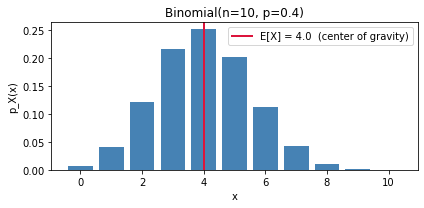

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

n_b, p_b = 10, 0.4
ks = np.arange(0, n_b + 1)
pmf = np.array([comb(n_b, k) * p_b**k * (1 - p_b) ** (n_b - k) for k in ks])
EX = (ks * pmf).sum()

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(ks, pmf, color="steelblue")
ax.axvline(EX, color="crimson", linewidth=2, label=f"E[X] = {EX:.1f}  (center of gravity)")
ax.set_xlabel("x")
ax.set_ylabel("p_X(x)")
ax.set_title(f"Binomial(n={n_b}, p={p_b})")
ax.legend()
plt.tight_layout()
plt.show()